In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cv2

In [2]:
import glob
import os
import seaborn as sns
import pandas as pd

from scipy.optimize import curve_fit
from tools.tools import *

radius = 5.5e-6 #Bead size m
rho = 1.3 * 1000 #Bead density kg/m^3
mu_0 = 4*np.pi*1e-7 #permeability
phase = 5
m = 3.5/(10*0.3*3.3)*1e-6
frame = (1544, 2064)

level = 5
#Parameters to crop simulation
height = 1544*m #height of FoV in µm
width = 2064*m #width of FoV in µm

#Parameters to crop simulation
height = 1544*m #height of FoV in µm
width = 2064*m #width of FoV in µm

start_w =  0#0.0035 - width #flip
end_w = width


root = "./data"
paths = glob.glob(os.path.join(root,"*.dat"))

df_bead = []

for count,i in enumerate(paths):
    ending = i.split("\\")[-1]
    parts = ending.split("_")
    day = parts[0]
    weight = float(parts[2][:-6])*1e-6 #*0.0275

    df_sub = pd.read_csv(i, sep= ",", skiprows = np.arange(0,34), encoding='latin-1').iloc[1:, :].dropna(how='all', axis = "columns")
    df_sub["sample"] = count
    df_sub["weight"] = weight

    #Oe  1/(4pi)*10^3 A/m
    df_sub["H"] = df_sub["Magnetic Field (Oe)"] * 1/(4*np.pi)*1e3
    #= 1 emu 10−3 A·m2
    df_sub["moment"] = df_sub["Moment (emu)"]*1e-3

    start_sat = np.where(df_sub["H"][:125].values>600e3)[0][0]
    end_sat = np.argmax(df_sub["H"][:125].values)

    k = np.polyfit(df_sub["H"][start_sat:end_sat].values,df_sub["moment"][start_sat:end_sat].values-df_sub["moment"][start_sat:end_sat].values[0],deg = 1, cov = False)
    offset = k[0]*df_sub["H"]

    df_sub["moment"] = df_sub["moment"] - offset
    df_sub["M_mass"] = df_sub["moment"]/(weight)
    df_sub["Measurement"] = f"Measurement {count}"

    if count == 0:
        df_bead = df_sub
    else:
        df_bead = pd.concat((df_bead,df_sub))


df_bead = df_bead.reset_index(drop=True)
df_stored = df_bead.copy().reset_index(drop=True)

df_stored["H"] = df_stored["H"].round(-1)
df_stored["M"] = df_stored["M_mass"]* rho

df_bead["H_round"] = np.round(df_bead["H"].values, -5)
fd_mean = df_bead.groupby(["H_round"]).mean(numeric_only=True).reset_index()
mask = fd_mean["H"].values >= 0
xdata = np.linspace(0,800000,1000)
popt, pcov = curve_fit(func_Fk, fd_mean["H_round"][mask], fd_mean["M_mass"][mask], method = "dogbox", bounds = [[0,0],[10,np.inf]])
ydata = func_Fk(xdata, *popt)

M_mag = ydata*rho
B_mag = xdata*mu_0


# fig, ax = plt.subplots(1,2, figsize=(8,6))
# sns.lineplot(x = "H", y = "M_mass", data = df_stored, hue = "Measurement", ax=ax[0], errorbar="sd")
# ax[0].legend(title="", loc = "upper left") 
# ax[1].plot(xdata, M_mag, "--", color = "C1")
# # ax[0].set_xlabel("Magnetic field H (A/m)")
# plt.show()


def load_simulation(path, time_stamps, di = 1):

    global start_w, end_w, start_h, end_h, frame
    
    if not time_stamps:
        columns_ = ["x", "y", "By", "Bx"]
        df_sim = pd.read_csv(path, sep = ",", skiprows= np.arange(0,8))
        df_sim.columns =columns_
    else:
        df_sim = pd.read_csv(path, sep = ",", skiprows= np.arange(0,8))
        columns_ = ["x","y"]


        for i in (np.arange((df_sim.shape[1]-2)//2)):
            columns_.append("Bx_{}".format(i))
            columns_.append("By_{}".format(i))

        df_sim.columns = columns_    

    field_dict = {"xx__":[], "yy__":[],  "X1": [], "Y1":[], "B": {}, "dBx":{},  "dBy":{}, "Bx":{}, "By":{}}

    df_sim["x"] = np.round(df_sim["x"], 5) #- (0.0035 - width)
    df_sim["y"] = np.round(df_sim["y"], 5) #- (0.003 - height/2)
    map_x = df_sim["x"].values
    map_y = df_sim["y"].values
    field_dict["xx__"] = np.linspace(start_w,end_w, frame[1]) #- (0.0035 - width)
    field_dict["yy__"] = np.linspace(start_h,end_h, frame[0]) #- (0.003 - height/2)
    y_unique = np.unique(map_y) 
    x_unique = np.unique(map_x) 
    y_u = len(np.unique(map_y))
    x_u = len(np.unique(map_x))
    
    field_dict["y_coord"] = np.concatenate((x_unique, x_unique[1:]+np.max(x_unique))) - start_h 
    field_dict["x_coord"] = y_unique + -1*np.min(y_unique)
    
    field_dict["X1"], field_dict["Y1"] = np.meshgrid(field_dict["x_coord"], field_dict["y_coord"])

    # Use actual displayed-grid spacings for gradients.
    dx_grid = float(np.mean(np.diff(field_dict["x_coord"]))) if len(field_dict["x_coord"]) > 1 else 1e-5
    dy_grid = float(np.mean(np.diff(field_dict["y_coord"]))) if len(field_dict["y_coord"]) > 1 else 1e-5

    for idx, i in enumerate(zip(columns_[2::2], columns_[3::2])):
        df_sim[i[0]] = scipy.ndimage.gaussian_filter1d(df_sim[i[0]].values,5) 
        df_sim[i[1]] = scipy.ndimage.gaussian_filter1d(df_sim[i[1]].values,5)
        
        df_sim["B_{}".format(idx)] = np.sqrt((df_sim[i[0]].values)**2 +  df_sim[i[1]].values**2)

        # Scalar |B| map: rotate and mirror-stack to match X1/Y1 layout.
        B = df_sim["B_{}".format(idx)].values
        B = B.reshape((y_u, x_u))
        B = np.rot90(B, k=-1)
        BB = np.vstack((B[::-1,:], B[1:,:]))

        Bx_raw = df_sim[i[0]].values.reshape((y_u, x_u))
        By_raw = df_sim[i[1]].values.reshape((y_u, x_u))

        Bx_rot = np.rot90(Bx_raw, k=-1)
        By_rot = np.rot90(By_raw, k=-1)

        U_rot = By_rot
        V_rot = Bx_rot

        BBx = np.vstack((U_rot[::-1, :], U_rot[1:, :]))
        BBy = np.vstack((V_rot[::-1, :], -V_rot[1:, :]))

        field_dict["B"]["B_{}".format(idx)] = scipy.ndimage.gaussian_filter(BB, 5)
        
        field_dict["dBx"]["dBx_{}".format(idx)] = scipy.ndimage.gaussian_filter(
            np.gradient(field_dict["B"]["B_{}".format(idx)], dx_grid, axis=1), 5
        )
        field_dict["dBy"]["dBy_{}".format(idx)] = scipy.ndimage.gaussian_filter(
            np.gradient(field_dict["B"]["B_{}".format(idx)], dy_grid, axis=0), 5
        )

        field_dict["Bx"]["Bx_{}".format(idx)] = scipy.ndimage.gaussian_filter(BBx, 5)
        field_dict["By"]["By_{}".format(idx)] = scipy.ndimage.gaussian_filter(BBy, 5)


    return field_dict, df_sim


path = "./data/One_coil_dense_t_angle.csv"
field_dict, df_sim = load_simulation(path, time_stamps=True, di=1)

X1 = field_dict["X1"]
Y1 = field_dict["Y1"]   
xx__ = field_dict["xx__"] #- (0.0035 - width)
yy__ = field_dict["yy__"] #- (0.003 - height/2)

def calc_force(dB, B ):
    global radius
    sim_force_martrix = np.zeros_like(dB)
    volume = 4/3 * np.pi * radius**3

    for i in range(dB.shape[0]):
        for j in range(dB.shape[1]):
            M_B = M_mag[np.argmin(np.abs(B_mag-B[i,j]))]  #B_mag, M_mag)
            sim_force_martrix[i,j] = volume*M_B*dB[i,j]

    sim_force_martrix = scipy.ndimage.gaussian_filter(sim_force_martrix, 5)

    return sim_force_martrix

c:\Users\lehto\git\OneCoilMicroRheometer\Analysis\tools\tools.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  return x/(1/x_0 + np.abs(x)/H_sat)


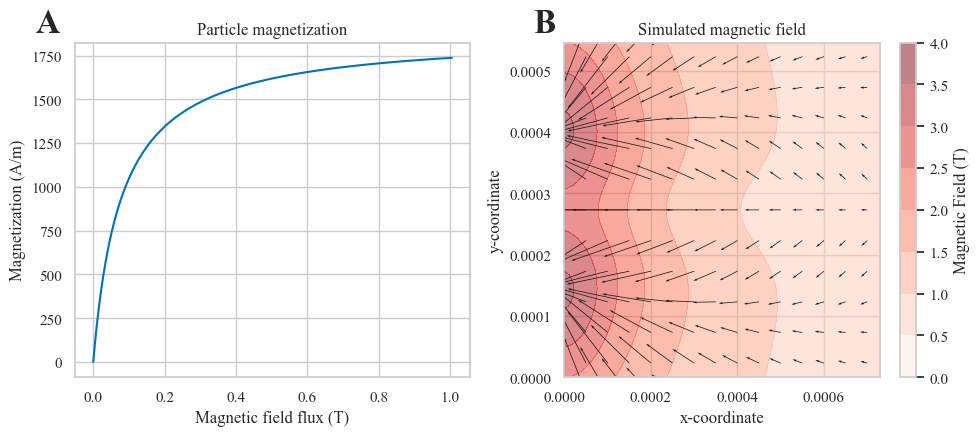

In [3]:
phase = 5
level = 5

fig = plt.figure(figsize = (10,8))

ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)

# ax2.contourf(xx__, yy__, test_frame, alpha = 1, cmap="binary")
CS = ax2.contourf(field_dict["x_coord"], field_dict["y_coord"], field_dict["B"]["B_{}".format(level)], alpha = 0.5, cmap = "Reds")
ax2.quiver(X1[::phase, ::phase], Y1[::phase, ::phase], field_dict["dBx"]["dBx_{}".format(level)][::phase,::phase], field_dict["dBy"]["dBy_{}".format(level)][::phase,::phase], angles = "xy") #dBy[::phase,::phase],dBx[::phase,::phase]

end_h_ = end_h - start_h
start_h_ = start_h - start_h

ax2.set_xlim([start_w,end_w])
ax2.set_ylim([start_h_,end_h_])

ax1.plot(B_mag, M_mag)
ax1.set_title("Particle magnetization")
ax1.set_xlabel("Magnetic field flux (T)")
ax1.set_ylabel("Magnetization (A/m)")

ax2.set_title("Simulated magnetic field")
ax2.set_xlabel("x-coordinate")
ax2.set_ylabel("y-coordinate")

cbar = fig.colorbar(CS)
cbar.ax.set_ylabel('Magnetic Field (T)')

add_panel_labels([ax1, ax2])
plt.tight_layout()


#fig.savefig('./figures/forces.png') 

In [4]:
mu0 = 4 * np.pi * 1e-7
r = 5.5e-6
v = 4.0 / 3.0 * np.pi * (r)**3

# Grid coordinates
x = np.asarray(field_dict["x_coord"], dtype=float)
y = np.asarray(field_dict["y_coord"], dtype=float)
xx, yy = np.meshgrid(x, y)

# Field components (H = B / mu0)
Hy = (1.0 / mu0) * field_dict["Bx"][f"Bx_{level}"]
Hx = (1.0 / mu0) * field_dict["By"][f"By_{level}"]
Hz = np.zeros_like(Hx)

# Spatial gradients of each H component.
# For 2D arrays: np.gradient returns [d()/dy, d()/dx].
dHx_dy, dHx_dx = np.gradient(Hx, y, x, edge_order=2)
dHy_dy, dHy_dx = np.gradient(Hy, y, x, edge_order=2)

H_mag = np.sqrt(Hx**2 + Hy**2 + Hz**2)
dHdy, dHdx = np.gradient(H_mag, y, x, edge_order=2)
# H_mag = scipy.ndimage.gaussian_filter(H_mag, sigma=5)

M_abs = np.zeros_like(H_mag)
M_mag_angle = np.zeros_like(H_mag)
for i in range(H_mag.shape[0]):
    for j in range(H_mag.shape[1]):
        M_abs[i, j] = M_mag[np.argmin(np.abs(B_mag - mu0 * H_mag[i, j]))]
        M_mag_angle[i, j] = np.degrees(np.arctan2(Hy[i, j], Hx[i, j]))

Maximum difference occurs at theta = 55.4545 deg, phi = 34.9981 deg


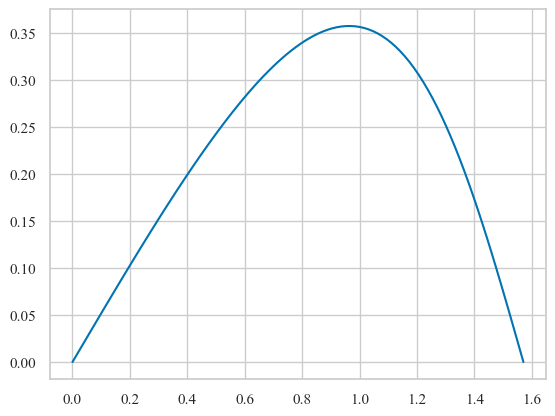

In [6]:
# Assume 0.9 difference in susceptibility.
r = 1/0.97
prolate = True  # Set to False for oblate spheroid

if prolate:
    n_a = 1/(r**2-1)*(r/(2*np.sqrt(r**2-1))*np.log((r+np.sqrt(r**2-1))/(r-np.sqrt(r**2-1)))-1)
    n_r = 1-n_a
else:
    n_a = r**2/(r**2-1)*(1-1/(np.sqrt(r**2-1))*np.arcsin(np.sqrt(r**2-1)/r))
    n_r = 1-n_a

theta = np.linspace(0, np.pi/2, 100)
phi = np.arctan(n_a/n_r*np.tan(theta))

max_dif = np.argmax(np.abs(np.abs(phi) - np.abs(theta)))
max_angle = theta[max_dif]
print(f"Maximum difference occurs at theta = {np.rad2deg(max_angle):.4f} deg, phi = {np.rad2deg(phi[max_dif]):.4f} deg")
plt.plot(theta, np.abs(np.abs(phi) - np.abs(theta)))

max_angle_difference = np.abs(np.abs(phi[max_dif]) - np.abs(theta[max_dif]))


mean |B| = 1.402e+00 T
mean |F_exact| = 4.050e-09 N
mean |F_approx| = 4.338e-09 N
RMS error Angle = 9.98 deg
RMS error Force magnitude = 4.52e-10 N


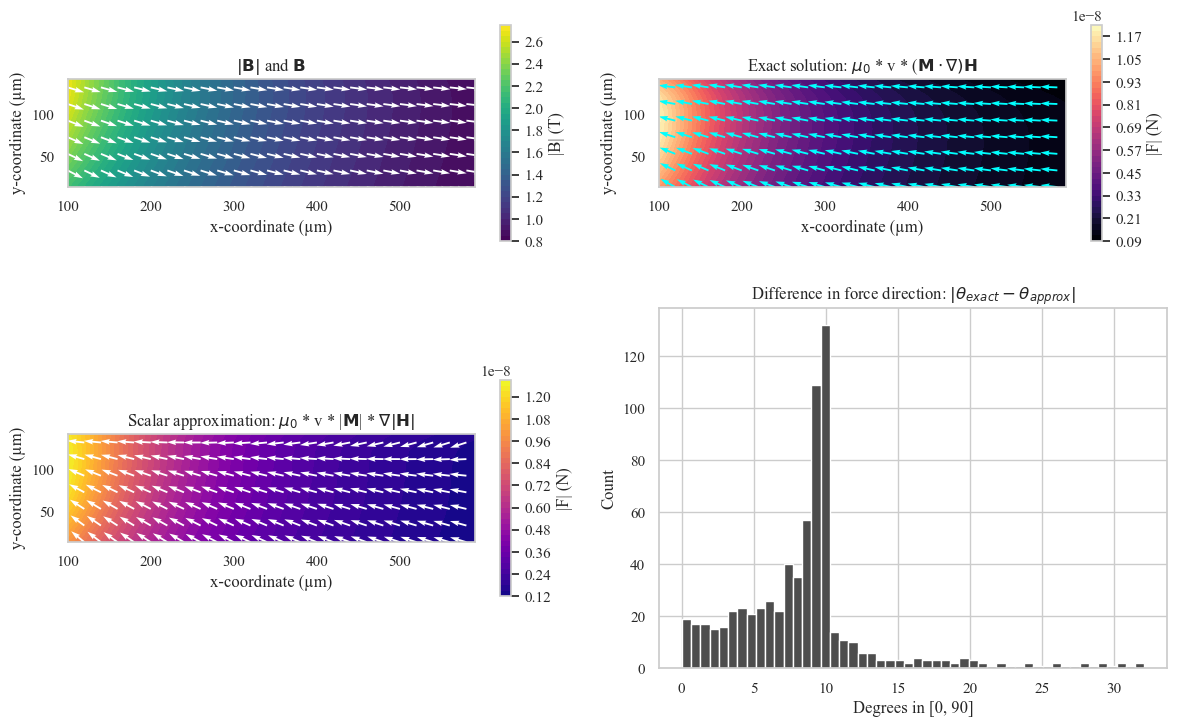

In [12]:
test_angle = max_angle_difference

Mx = np.cos( np.radians(M_mag_angle)- test_angle*np.ones_like(M_abs)) * M_abs
My = np.sin( np.radians(M_mag_angle)- test_angle*np.ones_like(M_abs)) * M_abs
Mz = 0 * Hz

M_mag = np.sqrt(Mx**2 + My**2 + Mz**2)

# Eq. (17): F = mu0 * v * (M · grad)H
Fx = mu0 * v * (Mx * dHx_dx + My * dHx_dy)
Fy = mu0 * v * (Mx * dHy_dx + My * dHy_dy)
F_mag = np.sqrt(Fx**2 + Fy**2)

# Eq. (20): F = mu0 * v * |M| * grad(|H|).
Fx_approx = mu0 * v * M_mag * dHdx
Fy_approx = mu0 * v * M_mag * dHdy
F_approx_mag = np.sqrt(Fx_approx**2 + Fy_approx**2)

# Requested crop rectangle
x_crop = (1.0e-4, 6.0e-4)
y_crop = (1.0e-5, 1.5e-4)

ix0 = int(np.searchsorted(x, x_crop[0], side="left"))
ix1 = int(np.searchsorted(x, x_crop[1], side="right") - 1)
iy0 = int(np.searchsorted(y, y_crop[0], side="left"))
iy1 = int(np.searchsorted(y, y_crop[1], side="right") - 1)

ix0 = max(0, min(ix0, len(x) - 1))
ix1 = max(0, min(ix1, len(x) - 1))
iy0 = max(0, min(iy0, len(y) - 1))
iy1 = max(0, min(iy1, len(y) - 1))

sx = slice(ix0, ix1 + 1)
sy = slice(iy0, iy1 + 1)

xx_c = xx[sy, sx]
yy_c = yy[sy, sx]
H_mag_c = H_mag[sy, sx]
F_mag_c = F_mag[sy, sx]

F_approx_mag_c = F_approx_mag[sy, sx]
Hx_c, Hy_c = Hx[sy, sx], Hy[sy, sx]
Fx_c, Fy_c = Fx[sy, sx], Fy[sy, sx]
Fx_a_c, Fy_a_c = Fx_approx[sy, sx], Fy_approx[sy, sx]

def unit_vec(U, V):
    m = np.hypot(U, V)
    return U / np.maximum(m, 1e-18), V / np.maximum(m, 1e-18)

Hx_u, Hy_u = unit_vec(Hx_c, Hy_c)
Fx_u, Fy_u = unit_vec(Fx_c, Fy_c)
Fx_a_u, Fy_a_u = unit_vec(Fx_a_c, Fy_a_c)

F_angle = np.degrees(np.arctan2(Fy_u, Fx_u))
F_approx_angle = np.degrees(np.arctan2(Fy_a_u, Fx_a_u))
angle_diff_force = np.abs(F_angle - F_approx_angle)

for i in range(angle_diff_force.shape[0]):
    for j in range(angle_diff_force.shape[1]):
        if angle_diff_force[i, j] > 90:
            angle_diff_force[i, j] = 180-angle_diff_force[i, j] % 180 

pha = 2
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

im0 = ax[0, 0].contourf(xx_c*1e6, yy_c*1e6, mu0*H_mag_c, levels=40, cmap="viridis")
ax[0, 0].quiver(xx_c[::pha, ::pha]*1e6, yy_c[::pha, ::pha]*1e6, mu0*Hx_u[::pha, ::pha], mu0*Hy_u[::pha, ::pha], color="white", angles="xy", scale_units="xy")
ax[0, 0].set_title(r"$|\mathbf{B}|$ and $\mathbf{B}$")
fig.colorbar(im0, ax=ax[0, 0], label="|B| (T)", shrink=0.6)

im1 = ax[0, 1].contourf(xx_c*1e6, yy_c*1e6, F_mag_c, levels=40, cmap="magma")
ax[0, 1].quiver(xx_c[::pha, ::pha]*1e6, yy_c[::pha, ::pha]*1e6, Fx_u[::pha, ::pha], Fy_u[::pha, ::pha], color="cyan", angles="xy", scale_units="xy")
ax[0, 1].set_title(r"Exact solution: $\mu_0$ * v * ($\mathbf{M} \cdot \nabla)\mathbf{H}$")
fig.colorbar(im1, ax=ax[0, 1], label="|F| (N)", shrink=0.6)

im2 = ax[1, 0].contourf(xx_c*1e6, yy_c*1e6, F_approx_mag_c, levels=40, cmap="plasma")
ax[1, 0].quiver(xx_c[::pha, ::pha]*1e6, yy_c[::pha, ::pha]*1e6, Fx_a_u[::pha, ::pha], Fy_a_u[::pha, ::pha], color="white", angles="xy", scale_units="xy")
ax[1, 0].set_title(r"Scalar approximation: $\mu_0$ * v * |$\mathbf{M}$| * $\nabla|\mathbf{H}|$")
fig.colorbar(im2, ax=ax[1, 0], label="|F| (N)", shrink=0.6)

_ = ax[1, 1].hist(angle_diff_force.ravel(), bins=50, color="0.3", edgecolor="white")
ax[1, 1].set_title(r'Difference in force direction: $|\theta_{exact} - \theta_{approx}|$')
ax[1, 1].set_xlabel("Degrees in [0, 90]")
ax[1, 1].set_ylabel("Count")

ax[0,0].set_xlabel("x-coordinate (µm)")
ax[0,0].set_ylabel("y-coordinate (µm)")
ax[0,1].set_xlabel("x-coordinate (µm)")
ax[0,1].set_ylabel("y-coordinate (µm)")
ax[1,0].set_xlabel("x-coordinate (µm)")
ax[1,0].set_ylabel("y-coordinate (µm)")

for a in [ax[0, 0], ax[0, 1], ax[1, 0]]:
    a.set_xlim([x[ix0]*1e6, x[ix1]*1e6])
    a.set_ylim([y[iy0]*1e6, y[iy1]*1e6])
    a.set_aspect("equal", adjustable="box")

print(f"mean |B| = {mu0*np.mean(H_mag_c):.3e} T")
# print(f"mean |M| = {np.mean(M_mag_c):.3e} A/m")
print(f"mean |F_exact| = {np.mean(F_mag_c):.3e} N")
print(f"mean |F_approx| = {np.mean(F_approx_mag_c):.3e} N")

print(f"RMS error Angle = {np.sqrt(np.mean(angle_diff_force**2)):.2f} deg")
print(f"RMS error Force magnitude = {np.sqrt(np.mean((F_mag_c - F_approx_mag_c)**2)):.2e} N")


plt.tight_layout()
plt.show()


In [10]:
np.sqrt(np.mean((F_mag_c - F_approx_mag_c)**2))/np.mean(F_mag_c)

0.1302625024716963

In [100]:
from glob import glob

# paths = glob('C:/Users/lehto/git/MicrorheologyProto/Calibration_V2/*/*.mp4')
# paths += glob('C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/results/calibs/*/*.mp4')
# i= 0
# video = cv2.VideoCapture(paths[i])

paths = glob('C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads/*.png')

paths

['C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_1.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_10.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_2.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_3.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_4.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_5.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_6.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_7.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_8.png',
 'C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\\img_9.png']

In [107]:

def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.0, threshold=0):
    """Return a sharpened version of the image, using an unsharp mask."""
    blurred = cv2.GaussianBlur(image, kernel_size, sigma)
    sharpened = float(amount + 1) * image - float(amount) * blurred
    sharpened = np.maximum(sharpened, np.zeros(sharpened.shape))
    sharpened = np.minimum(sharpened, 255 * np.ones(sharpened.shape))
    sharpened = sharpened.round().astype(np.uint8)
    if threshold > 0:
        low_contrast_mask = np.absolute(image - blurred) < threshold
        np.copyto(sharpened, image, where=low_contrast_mask)
    return sharpened

def get_aspect_ratios(frame_org, r, m):
    if frame_org is None or frame_org.size == 0:
        return np.zeros((1, 1, 3), dtype=np.uint8), [], np.zeros((1, 1), dtype=np.uint8)

    frame = frame_org.copy()
    vis = frame.copy()
    h, w = frame.shape[:2]

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    x0 = int(0.12 * w)
    roi_mask = np.zeros_like(gray, dtype=np.uint8)
    roi_mask[:, x0:] = 255

    bg = cv2.GaussianBlur(gray, (0, 0), 31)
    flat = cv2.subtract(bg, gray)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
    flat = clahe.apply(flat)
    flat = unsharp_mask(flat, kernel_size=(5, 5), sigma=1.0, amount=1.0, threshold=0)
    
    _, bw = cv2.threshold(flat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bw = cv2.bitwise_and(bw, roi_mask)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k, iterations=1)
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, k, iterations=1)

    cnt, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bead_area = np.pi * (r / m) ** 2
    min_a =  np.pi * ((r-0.5e-6) / m) ** 2
    max_a =  np.pi * ((r+0.5e-6) / m) ** 2
    min_p = 2 * np.pi * ((r-0.5e-6) / m)
    max_p = 2 * np.pi * ((r+0.5e-6) / m)

    aspect_ratios = []
    radius_list = []

    for c in cnt:
        area = cv2.contourArea(c)

        if area < min_a or area > max_a:
            continue
        
        perimeter = cv2.arcLength(c, True)
        if (perimeter < min_p) or (perimeter > max_p):
            continue

        if len(c) < 5:
            continue

        (cx, cy), (a1, a2), _ = cv2.fitEllipse(c)

        major = max(a1, a2)
        minor = min(a1, a2)
        ar = minor / major

        x, y, ww, hh = cv2.boundingRect(c)
        if x <= x0 or y <= 1 or (x + ww) >= (w - 1) or (y + hh) >= (h - 1):
            continue

        if ar < 0.75:
            continue

        aspect_ratios.append(ar)
        radius_list.append(m * (major + minor) / (4 ))

        # print(f"Aspect ratio: {ar:.3f}, Area: {area:.2f}, Perimeter: {perimeter:.2f}, Major: {major:.2f}, Minor: {minor:.2f}")

        cv2.drawContours(vis, [c], -1, (0, 255, 0), 2)
        cv2.putText(
            vis,
            f"{ar:.3f}",
            (int(cx), int(cy)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1,
        )

    return vis, aspect_ratios, radius_list, flat

Processed 1/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_1.png, Detected 16 beads
Processed 2/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_10.png, Detected 261 beads
Processed 3/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_2.png, Detected 16 beads
Processed 4/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_3.png, Detected 11 beads
Processed 5/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_4.png, Detected 8 beads
Processed 6/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_5.png, Detected 1 beads
Processed 7/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_6.png, Detected 0 beads
Processed 8/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_7.png, Detected 9 beads
Processed 9/10: C:/Users/lehto/git/OneCoilMicroRheometer/Analysis/data/beads\img_8.png, Detected 111 beads
Processed 10/10: C:/Users/lehto/git/OneCoilMicr

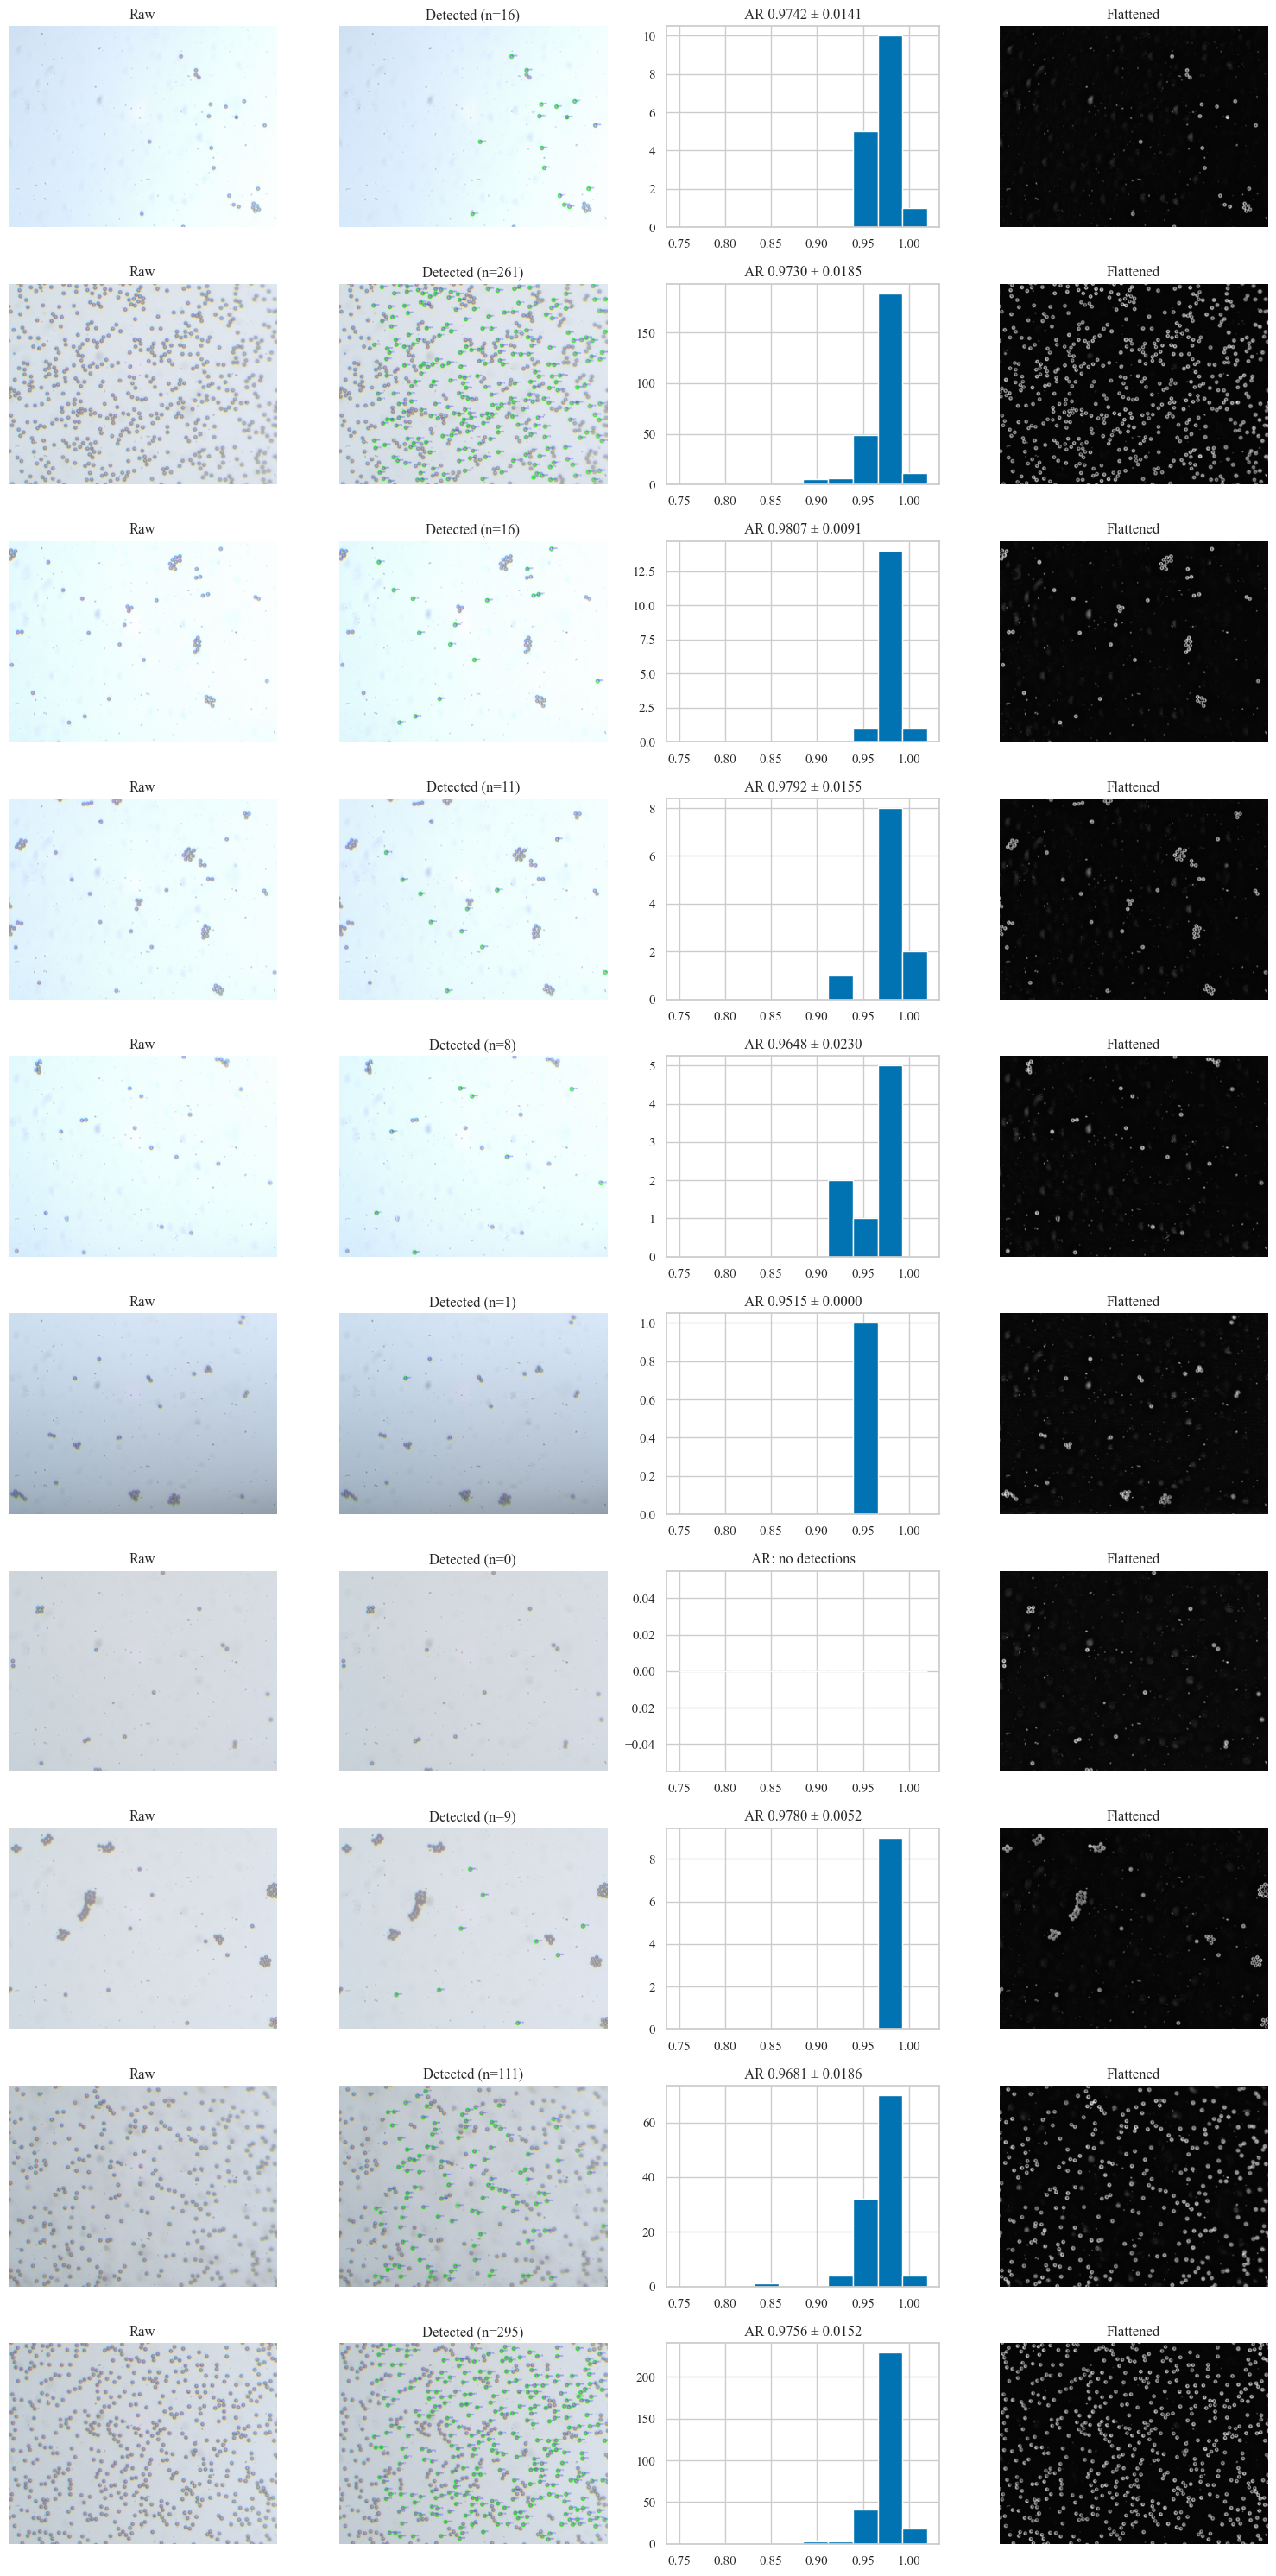

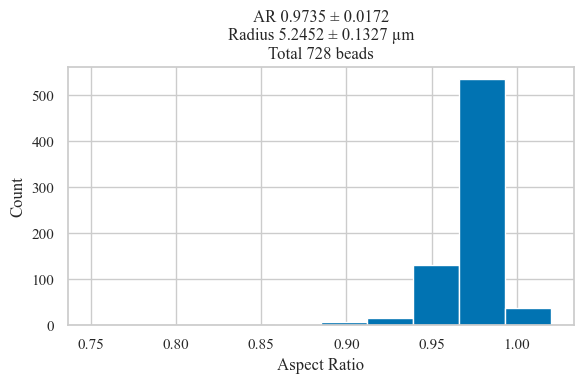

In [112]:
m =  3.5/(10*0.3*3.3)*1e-6
r = 5.5e-6
video_flag = False

N_paths = len(paths)
fig, ax = plt.subplots(N_paths, 4, figsize=(15, max(3 * N_paths, 6)))
if N_paths == 1:
    ax = np.expand_dims(ax, axis=0)

all_aspect_ratios = []
all_radius_list = []

for i, path in enumerate(paths):
    if video_flag:
        video = cv2.VideoCapture(path)
        ret, frame_org = video.read()
        video.release()
        if not ret:
            continue
    else:
        frame_org = cv2.imread(path)

    frame_to_vis, aspect_ratios, radius_list, flat = get_aspect_ratios(frame_org, r, m)

    ax[i, 0].imshow(cv2.cvtColor(frame_org, cv2.COLOR_BGR2RGB))
    ax[i, 0].set_title("Raw")
    ax[i, 0].axis("off")

    ax[i, 1].imshow(cv2.cvtColor(frame_to_vis, cv2.COLOR_BGR2RGB))
    ax[i, 1].set_title(f"Detected (n={len(aspect_ratios)})")
    ax[i, 1].axis("off")

    ax[i, 2].hist(aspect_ratios, bins=10, range=(0.75, 1.02))

    if len(aspect_ratios) > 0:
        ax[i, 2].set_title(f"AR {np.mean(aspect_ratios):.4f} ± {np.std(aspect_ratios):.4f}")
        all_aspect_ratios.extend(aspect_ratios)
        all_radius_list.extend(radius_list)
    else:
        ax[i, 2].set_title("AR: no detections")

    ax[i, 3].imshow(flat, cmap='gray')
    ax[i, 3].set_title("Flattened")
    ax[i, 3].axis("off")

    print(f"Processed {i+1}/{N_paths}: {path}, Detected {len(aspect_ratios)} beads")
    
fig.tight_layout()
plt.show()

all_aspect_ratios = np.asarray(all_aspect_ratios, dtype=float)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
if all_aspect_ratios.size > 0:
    ax.set_title(f"AR {all_aspect_ratios.mean():.4f} ± {all_aspect_ratios.std():.4f}\nRadius {np.mean(all_radius_list)*1e6:.4f} ± {np.std(all_radius_list)*1e6:.4f} µm\nTotal {all_aspect_ratios.size} beads")
    ax.hist(all_aspect_ratios, bins=10, range=(0.75, 1.02))
else:
    ax.set_title("No valid beads detected")

ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Count")

fig.tight_layout()
plt.show()



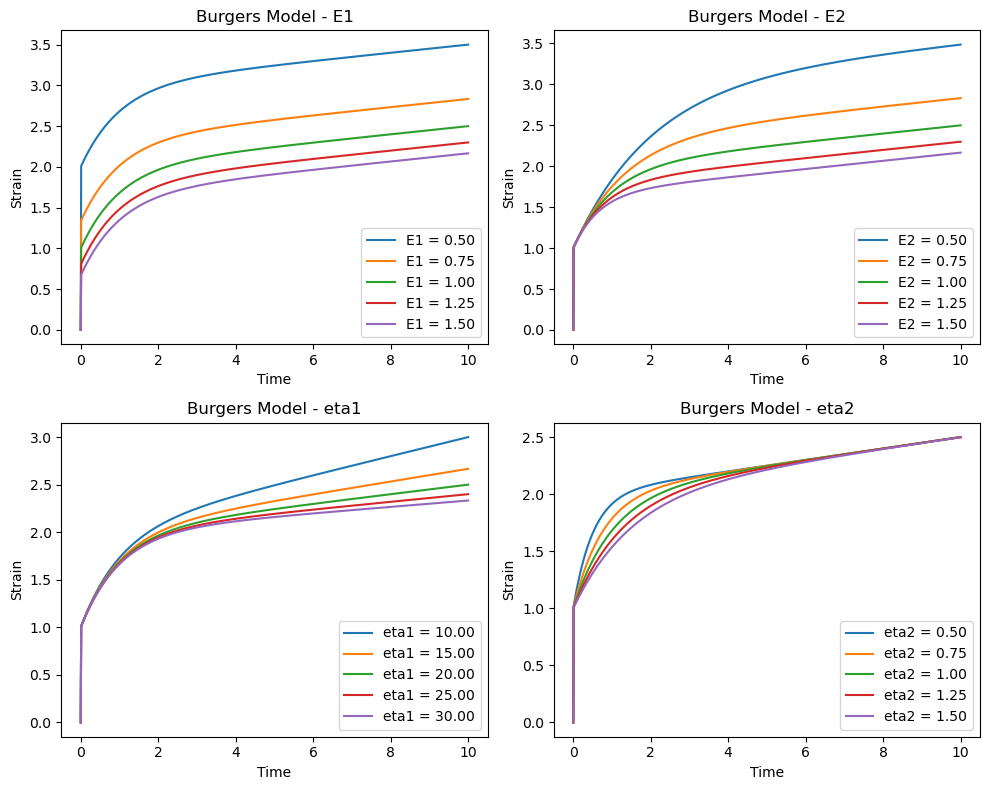

In [5]:
def burgers(t, E1, E2, eta1, eta2):
    return ((1 / E1) + (t / eta1) + (1.0 / E2) * (1.0 - np.exp(- (E2 * t) / eta2)))


t = np.linspace(0, 10, 1000)

param_names = ['E1', 'E2', 'eta1', 'eta2']


fig, ax = plt.subplots(2,2, figsize=(10, 8))

for idx in range(4):
    for i in np.linspace(0.5, 1.5, 5):
        param = [1.0, 1.0, 2e1, 1]
        param[idx] = i*param[idx]

        vec = burgers(t, param[0], param[1], param[2], param[3])
        vec[0] = 0.0
        ax[idx//2, idx%2].plot(t, vec, label=f'{param_names[idx]} = {param[idx]:.2f}')
        # ax[idx//2, idx%2].set_yscale('log')

    ax[idx//2, idx%2].set_xlabel('Time')
    ax[idx//2, idx%2].set_ylabel('Strain')
    ax[idx//2, idx%2].set_title(f'Burgers Model - {param_names[idx]}')
    ax[idx//2, idx%2].legend()


fig.tight_layout()
plt.show()

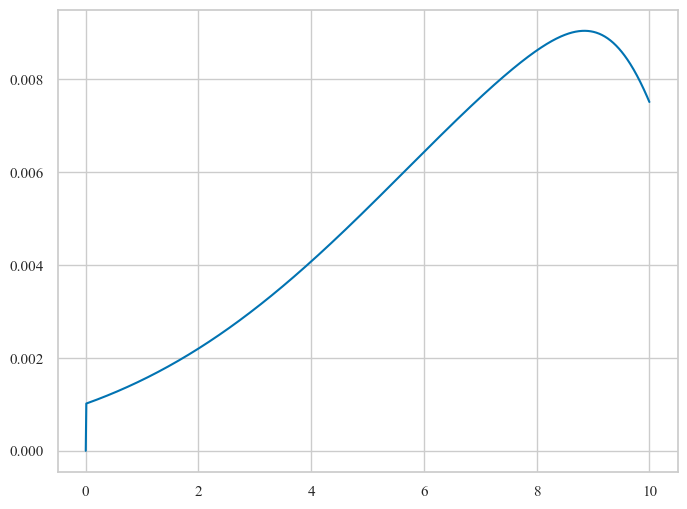

In [207]:
import scipy
def skewed_gaussian(x, A, mu, sigma, alpha):
    z = (x - mu) / sigma
    return A * np.exp(-0.5 * z**2) * 0.5 * (1 + scipy.special.erf(alpha * z / np.sqrt(2)))


f = skewed_gaussian(t, 0.01, -0.7, 5.0, 5.0)
f = np.flip(f)
f[0] = 0
plt.figure(figsize=(8, 6))
plt.plot(t, f, label='Skewed Gaussian')

\begin{tabular}{ccccc}
\hline
Bias & $E_1$ & $E_2$ & $\eta_1$ & $\eta_2$ \\
\hline
0.00 & 1.0635 & 0.9898 & 111.3769 & 0.8548 \\
0.12 & 1.0675 & 1.0217 & 42.8708 & 0.8467 \\
0.25 & 1.0717 & 1.0539 & 26.7259 & 0.8380 \\
0.38 & 1.0759 & 1.0864 & 19.5081 & 0.8286 \\
0.50 & 1.0801 & 1.1191 & 15.4164 & 0.8187 \\
\hline
\end{tabular}


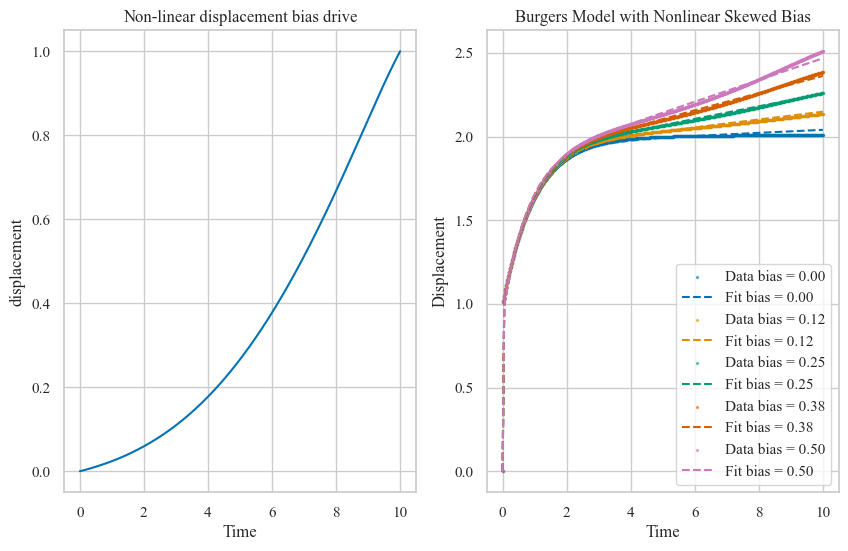

In [208]:
from scipy.optimize import curve_fit

dt = t[1] - t[0]
sigma = 1.0 + 10.0 * (t / max(t.max(), 1e-9)) ** 2

base_response = burgers(t, 1.0, 1.0, 1e3, 1)
base_response[0] = 0.0

f = skewed_gaussian(t, 1.0, -0.7, 5.0, 5.0)
f = np.flip(f)
f[0] = 0.0

bias_drive = np.cumsum(f) * dt
bias_drive = bias_drive / max(np.max(np.abs(bias_drive)), 1e-12)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].plot(t, bias_drive, label='Bias Response')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('displacement')
ax[0].set_title('Non-linear displacement bias drive')

fit_rows = []

for idx, bias_level in enumerate(np.linspace(0.0, 0.5, 5)):
    # Nonlinear bias: skewed cumulative drive passed through a
    # power law
    nonlinear_bias = bias_level * np.abs(bias_drive) #** 1.5
    probe_data = base_response + nonlinear_bias
    probe_data[0] = 0.0
    ax[1].scatter(t, probe_data, label=f'Data bias = {bias_level:.2f}', color = f'C{idx}', alpha=0.5, s=2)

    p_burgers, _ = curve_fit(
        burgers,
        t,
        probe_data,
        method='dogbox',
        bounds=([1e-12, 1e-12, 1e-12, 1e-12], [np.inf, np.inf, np.inf, np.inf]),
        sigma=sigma,
        maxfev=200000,
    )

    fit_rows.append((bias_level, p_burgers[0], p_burgers[1], p_burgers[2], p_burgers[3]))

    x_fit = np.linspace(0, t.max(), num=200)
    y_burgers = burgers(x_fit, *p_burgers)
    y_burgers[0] = 0.0

    ax[1].plot(x_fit, y_burgers, '--', label=f'Fit bias = {bias_level:.2f}', color = f'C{idx}')

latex_lines = [
    r'\begin{tabular}{ccccc}',
    r'\hline',
    r'Bias & $E_1$ & $E_2$ & $\eta_1$ & $\eta_2$ \\',
    r'\hline',
]
for bias_level, e1, e2, eta1, eta2 in fit_rows:
    latex_lines.append(
        f'{bias_level:.2f} & {e1:.4f} & {e2:.4f} & {eta1:.4f} & {eta2:.4f}' + r' \\'
    )
latex_lines.extend([r'\hline', r'\end{tabular}'])
print('\n'.join(latex_lines))

ax[1].set_xlabel('Time')
ax[1].set_ylabel('Displacement')
ax[1].set_title('Burgers Model with Nonlinear Skewed Bias')

plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1000,) and (601, 701)

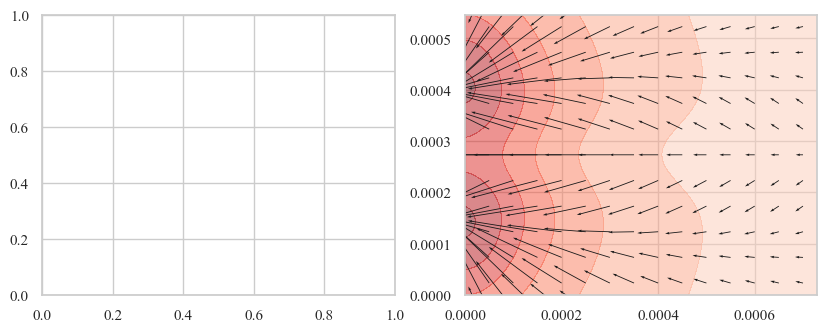

In [84]:
phase = 5
level = 5

fig = plt.figure(figsize = (10,8))

ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)

# ax2.contourf(xx__, yy__, test_frame, alpha = 1, cmap="binary")
CS = ax2.contourf(field_dict["x_coord"], field_dict["y_coord"], field_dict["B"]["B_{}".format(level)], alpha = 0.5, cmap = "Reds")
ax2.quiver(X1[::phase, ::phase], Y1[::phase, ::phase], field_dict["dBx"]["dBx_{}".format(level)][::phase,::phase], field_dict["dBy"]["dBy_{}".format(level)][::phase,::phase], angles = "xy") #dBy[::phase,::phase],dBx[::phase,::phase]

end_h_ = end_h - start_h
start_h_ = start_h - start_h

ax2.set_xlim([start_w,end_w])
ax2.set_ylim([start_h_,end_h_])

ax1.plot(B_mag, M_mag)
ax1.set_title("Particle magnetization")
ax1.set_xlabel("Magnetic field flux (T)")
ax1.set_ylabel("Magnetization (A/m)")

ax2.set_title("Simulated magnetic field")
ax2.set_xlabel("x-coordinate")
ax2.set_ylabel("y-coordinate")

cbar = fig.colorbar(CS)
cbar.ax.set_ylabel('Magnetic Field (T)')

add_panel_labels([ax1, ax2])
plt.tight_layout()


#fig.savefig('./figures/forces.png') 

mean |H| = 4.731e+00 A/m
mean |M| = 7.096e-01 A/m
mean |F_exact| = 7.389e-14 N
mean |F_approx| = 7.391e-14 N
mean angle diff exact vs approx = 0.00 deg


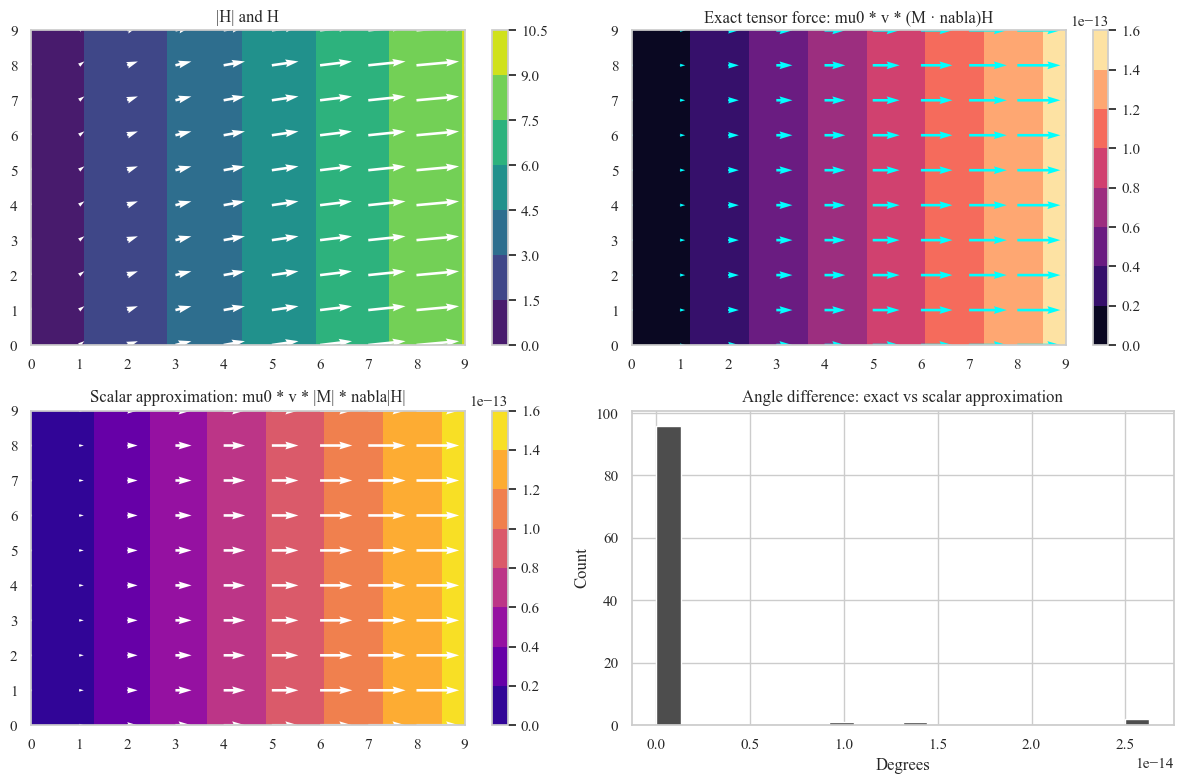

In [ ]:

mu0 = 4 * np.pi * 1e-7
v = 4.0 / 3.0 * np.pi * (5.5e-6 / 2.0)**3

x = np.arange(10)
y = np.arange(10)
xx, yy = np.meshgrid(x, y)

Hx = np.linspace(1.0e4, 2.0e4, 100).reshape(10, 10)
Hy = np.linspace(0.5e4, 1.5e4, 100).reshape(10, 10)

Hx = np.tile(np.arange(10), (10, 1))
Hy = np.tile(np.ones(10), (10, 1))

Hz = np.zeros_like(Hx)

# grad_H[j] is dH_j/dx, dH_j/dy, dH_j/dz, so we can form (M · ∇)H.
dHx_dy, dHx_dx = np.gradient(Hx, y, x, edge_order=2)
dHy_dy, dHy_dx = np.gradient(Hy, y, x, edge_order=2)
dHz_dy, dHz_dx = np.gradient(Hz, y, x, edge_order=2)
H_mag = np.sqrt(Hx**2 + Hy**2 + Hz**2)

# Assume a simple linear susceptibility and alignment with H.
chi = 0.15
H_hat_x = Hx / np.maximum(H_mag, 1e-12)
H_hat_y = Hy / np.maximum(H_mag, 1e-12)
H_hat_z = Hz / np.maximum(H_mag, 1e-12)

Mx = chi * Hx
My = chi * Hy
Mz = chi * Hz
M_mag_ = np.sqrt(Mx**2 + My**2 + Mz**2)


# Eq. (17): F = mu0 * v * (M · grad)H
# Fx = mu0 * v * (Mx*dHx/dx + My*dHx/dy + Mz*dHx/dz)
# Fy = mu0 * v * (Mx*dHy/dx + My*dHy/dy + Mz*dHy/dz)
# Fz = mu0 * v * (Mx*dHz/dx + My*dHz/dy + Mz*dHz/dz)
Fx = mu0 * v * (Mx * dHx_dx + My * dHx_dy)*1e9
Fy = mu0 * v * (Mx * dHy_dx + My * dHy_dy)*1e9
F_mag = np.sqrt(Fx**2 + Fy**2)

# Eq. (20): F = mu0 * v * |M| * grad(|H|).
dHdy, dHdx = np.gradient(H_mag, y, x, edge_order=2)
Fx_approx = mu0 * v * M_mag_ * dHdx*1e9
Fy_approx = mu0 * v * M_mag_ * dHdy*1e9
F_approx_mag = np.sqrt(Fx_approx**2 + Fy_approx**2)

core = np.s_[1:-1, 1:-1]
xx_c = xx[core]
yy_c = yy[core]
Hx_c = Hx[core]
Hy_c = Hy[core]
H_mag_c = H_mag[core]
Fx_c = Fx[core]
Fy_c = Fy[core]
F_mag_c = F_mag[core]
Fx_approx_c = Fx_approx[core]
Fy_approx_c = Fy_approx[core]
F_approx_mag_c = F_approx_mag[core]


F_angle = np.degrees(np.arctan2(Fy, Fx))
F_approx_angle = np.degrees(np.arctan2(Fy_approx, Fx_approx))
angle_diff_force = np.abs(F_angle - F_approx_angle)

# angle_diff_force = np.degrees(np.arctan2(
#     np.sin(np.radians(F_angle - F_approx_angle)),
#     np.cos(np.radians(F_angle - F_approx_angle))
# ))


fig, ax = plt.subplots(2, 2, figsize=(12, 8))

im0 = ax[0, 0].contourf(xx, yy, H_mag, cmap="viridis")
ax[0, 0].quiver(xx, yy, Hx, Hy, color="white", angles="xy", scale_units="xy", scale=np.max(H_mag)/1)
ax[0, 0].set_title("|H| and H")
fig.colorbar(im0, ax=ax[0, 0])

im1 = ax[0, 1].contourf(xx, yy, F_mag, cmap="magma")
ax[0, 1].quiver(xx, yy, Fx, Fy, color="cyan", angles="xy", scale_units="xy", scale=np.max(F_mag)/1)
ax[0, 1].set_title("Exact tensor force: mu0 * v * (M · nabla)H")
fig.colorbar(im1, ax=ax[0, 1])

im2 = ax[1, 0].contourf(xx, yy, F_approx_mag, cmap="plasma")
ax[1, 0].quiver(xx, yy, Fx_approx, Fy_approx, color="white", angles="xy", scale_units="xy", scale=np.max(F_approx_mag)/1)
ax[1, 0].set_title("Scalar approximation: mu0 * v * |M| * nabla|H|")
fig.colorbar(im2, ax=ax[1, 0])

_ = ax[1, 1].hist(angle_diff_force.ravel(), bins=20, color="0.3", edgecolor="white")
ax[1, 1].set_title("Angle difference: exact vs scalar approximation")
ax[1, 1].set_xlabel("Degrees")
ax[1, 1].set_ylabel("Count")

print(f"mean |H| = {np.mean(H_mag):.3e} A/m")
print(f"mean |M| = {np.mean(M_mag_):.3e} A/m")
print(f"mean |F_exact| = {np.mean(F_mag):.3e} N")
print(f"mean |F_approx| = {np.mean(F_approx_mag):.3e} N")
print(f"mean angle diff exact vs approx = {np.mean(angle_diff_force):.2f} deg")

plt.tight_layout()
plt.show()

In [449]:

def load_simulation(path, time_stamps, di = 1):

    global start_w, end_w, start_h, end_h, frame
    
    if not time_stamps:
        columns_ = ["x", "y", "By", "Bx"]
        df_sim = pd.read_csv(path, sep = ",", skiprows= np.arange(0,8))
        df_sim.columns =columns_
    else:
        df_sim = pd.read_csv(path, sep = ",", skiprows= np.arange(0,8))
        columns_ = ["x","y"]


        for i in (np.arange((df_sim.shape[1]-2)//2)):
            columns_.append("Bx_{}".format(i))
            columns_.append("By_{}".format(i))

        df_sim.columns = columns_    

    field_dict = {"xx__":[], "yy__":[],  "X1": [], "Y1":[], "B": {}, "dBx":{},  "dBy":{}, "Bx":{}, "By":{}}

    df_sim["x"] = np.round(df_sim["x"], 5) #- (0.0035 - width)
    df_sim["y"] = np.round(df_sim["y"], 5) #- (0.003 - height/2)
    map_x = df_sim["x"].values
    map_y = df_sim["y"].values
    field_dict["xx__"] = np.linspace(start_w,end_w, frame[1]) #- (0.0035 - width)
    field_dict["yy__"] = np.linspace(start_h,end_h, frame[0]) #- (0.003 - height/2)
    y_unique = np.unique(map_y) 
    x_unique = np.unique(map_x) 
    y_u = len(np.unique(map_y))
    x_u = len(np.unique(map_x))
    
    field_dict["y_coord"] = x_unique  #np.concatenate((x_unique, x_unique[1:]+np.max(x_unique))) - start_h 
    field_dict["x_coord"] = y_unique + -1*np.min(y_unique)
    
    field_dict["X1"], field_dict["Y1"] = np.meshgrid(field_dict["x_coord"], field_dict["y_coord"])

    # Use actual displayed-grid spacings for gradients.
    dx_grid = float(np.mean(np.diff(field_dict["x_coord"]))) if len(field_dict["x_coord"]) > 1 else 1e-5
    dy_grid = float(np.mean(np.diff(field_dict["y_coord"]))) if len(field_dict["y_coord"]) > 1 else 1e-5

    for idx, i in enumerate(zip(columns_[2::2], columns_[3::2])):
        df_sim[i[0]] = scipy.ndimage.gaussian_filter1d(df_sim[i[0]].values,5) 
        df_sim[i[1]] = scipy.ndimage.gaussian_filter1d(df_sim[i[1]].values,5)
        
        df_sim["B_{}".format(idx)] = np.sqrt((df_sim[i[0]].values)**2 +  df_sim[i[1]].values**2)

        # Scalar |B| map: rotate and mirror-stack to match X1/Y1 layout.
        B = df_sim["B_{}".format(idx)].values
        B = B.reshape((y_u, x_u))
        BB = np.rot90(B, k=-1)
        # BB = np.vstack((B[::-1,:], B[1:,:]))

        Bx_raw = df_sim[i[0]].values.reshape((y_u, x_u))
        By_raw = df_sim[i[1]].values.reshape((y_u, x_u))

        Bx_rot = np.rot90(Bx_raw, k=-1)
        By_rot = np.rot90(By_raw, k=-1)

        BBx = By_rot
        BBy = Bx_rot

        # BBx = np.vstack((U_rot[::-1, :], U_rot[1:, :]))
        # BBy = np.vstack((V_rot[::-1, :], -V_rot[1:, :]))

        field_dict["B"]["B_{}".format(idx)] = scipy.ndimage.gaussian_filter(BB, 5)
        field_dict["dBx"]["dBx_{}".format(idx)] = scipy.ndimage.gaussian_filter(
            np.gradient(field_dict["B"]["B_{}".format(idx)], dx_grid, axis=1), 5
        )
        field_dict["dBy"]["dBy_{}".format(idx)] = scipy.ndimage.gaussian_filter(
            np.gradient(field_dict["B"]["B_{}".format(idx)], dy_grid, axis=0), 5
        )

        field_dict["Bx"]["Bx_{}".format(idx)] = scipy.ndimage.gaussian_filter(BBx, 5)
        field_dict["By"]["By_{}".format(idx)] = scipy.ndimage.gaussian_filter(BBy, 5)


    return field_dict, df_sim


path = "./data/One_coil_dense_t_angle.csv"
field_dict, df_sim = load_simulation(path, time_stamps=True, di=1)

X1 = field_dict["X1"]
Y1 = field_dict["Y1"]   
xx__ = field_dict["xx__"] #- (0.0035 - width)
yy__ = field_dict["yy__"] #- (0.003 - height/2)



Crop indices (inclusive):
  y: [1, 15] -> [0.000010, 0.000150] m
  x: [10, 59] -> [0.000100, 0.000590] m
  crop shape: (15, 50)
mean |H| = 2.006e+05 A/m
mean |M| = 3.009e+04 A/m
mean |F_exact| = 1.139e-09 N
mean |F_approx| = 1.570e-09 N
mean acute angle diff exact vs approx = 21.37 deg
Force magnitude difference = -4.31e-10 N


C:\Users\lehto\AppData\Local\Temp\ipykernel_14964\899214771.py:131: UserWarning: Glyph 8711 (\N{NABLA}) missing from current font.
  plt.tight_layout()


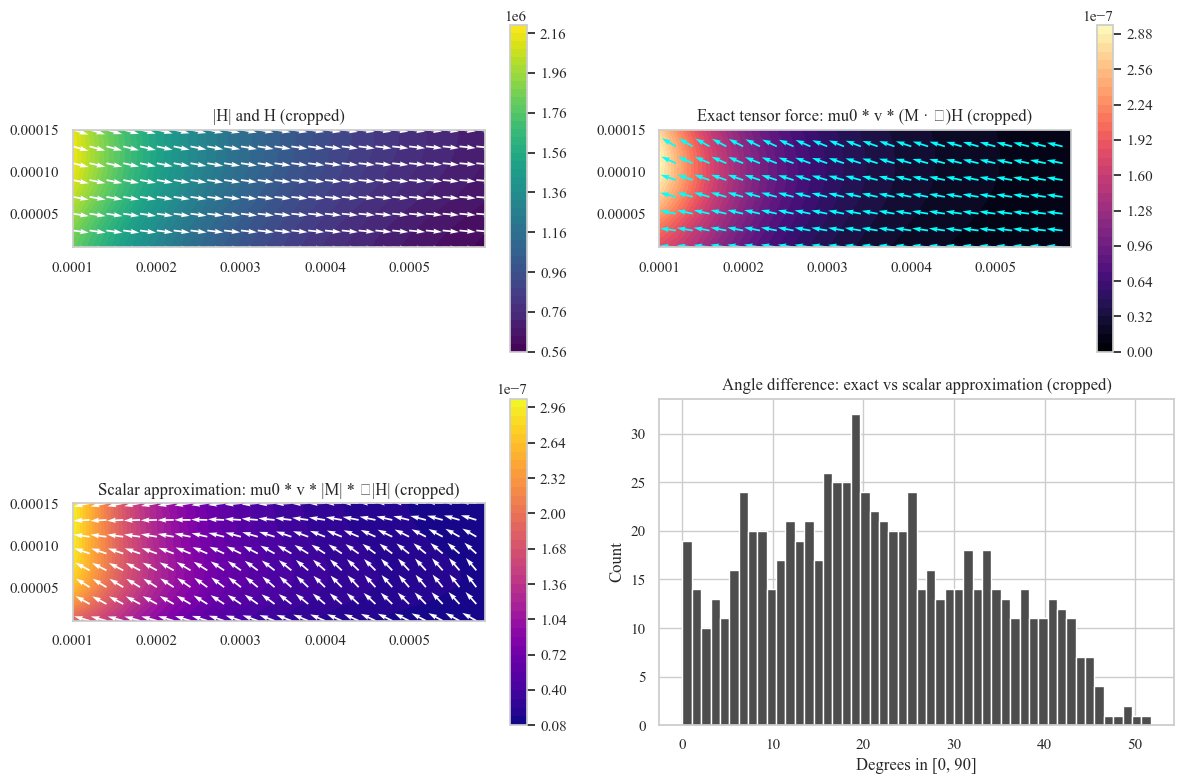

In [493]:
# Eq. (17)-(20) demo: force from a field with an assumed magnetization law.
# We assume the particle magnetization follows M = chi * H and is aligned with H.

mu0 = 4 * np.pi * 1e-7

# Grid coordinates
x = np.asarray(field_dict["x_coord"], dtype=float)
y = np.asarray(field_dict["y_coord"], dtype=float)
xx, yy = np.meshgrid(x, y)

# Field components (H = B / mu0)
Hy = (1.0 / mu_0) * field_dict["Bx"][f"Bx_{level}"]
Hx = (1.0 / mu_0) * field_dict["By"][f"By_{level}"]
Hz = np.zeros_like(Hx)

# Spatial gradients of each H component.
# For 2D arrays: np.gradient returns [d()/dy, d()/dx].
dHx_dy, dHx_dx = np.gradient(Hx, y, x, edge_order=2)
dHy_dy, dHy_dx = np.gradient(Hy, y, x, edge_order=2)

# Assume a simple linear susceptibility and alignment with H.
chi = 0.15
H_mag = np.sqrt(Hx**2 + Hy**2 + Hz**2)
Mx = chi * Hx
My = chi * Hy
Mz = chi * Hz
M_mag = np.sqrt(Mx**2 + My**2 + Mz**2)

# Eq. (17): F = mu0 * v * (M · grad)H
v = 4.0 / 3.0 * np.pi * (5.5e-6 / 2.0) ** 3
Fx = mu0 * v * (Mx * dHx_dx + My * dHx_dy)
Fy = mu0 * v * (Mx * dHy_dx + My * dHy_dy)
F_mag = np.sqrt(Fx**2 + Fy**2)

# Eq. (20): scalar approximation F ~ mu0 * v * |M| * grad(|H|).
BB = field_dict["B"][f"B_{level}"]
dHdy, dHdx = np.gradient(1/mu_0*BB, y, x, edge_order=1)

Fx_approx = mu0 * v * M_mag * dHdx
Fy_approx = mu0 * v * M_mag * dHdy
F_approx_mag = np.sqrt(Fx_approx**2 + Fy_approx**2)


# Requested crop rectangle
x_crop = (1.0e-4, 6.0e-4)
y_crop = (1.0e-5, 1.5e-4)

ix0 = int(np.searchsorted(x, x_crop[0], side="left"))
ix1 = int(np.searchsorted(x, x_crop[1], side="right") - 1)
iy0 = int(np.searchsorted(y, y_crop[0], side="left"))
iy1 = int(np.searchsorted(y, y_crop[1], side="right") - 1)

ix0 = max(0, min(ix0, len(x) - 1))
ix1 = max(0, min(ix1, len(x) - 1))
iy0 = max(0, min(iy0, len(y) - 1))
iy1 = max(0, min(iy1, len(y) - 1))


sx = slice(ix0, ix1 + 1)
sy = slice(iy0, iy1 + 1)

xx_c = xx[sy, sx]
yy_c = yy[sy, sx]
H_mag_c = H_mag[sy, sx]
F_mag_c = F_mag[sy, sx]

F_approx_mag_c = F_approx_mag[sy, sx]

Hx_c, Hy_c = Hx[sy, sx], Hy[sy, sx]
Fx_c, Fy_c = Fx[sy, sx], Fy[sy, sx]
Fx_a_c, Fy_a_c = Fx_approx[sy, sx], Fy_approx[sy, sx]

# Use normalized vectors for plotting to avoid edge-magnitude blowups.
def unit_vec(U, V):
    m = np.hypot(U, V)
    return U / np.maximum(m, 1e-18), V / np.maximum(m, 1e-18)

Hx_u, Hy_u = unit_vec(Hx_c, Hy_c)
Fx_u, Fy_u = unit_vec(Fx_c, Fy_c)
Fx_a_u, Fy_a_u = unit_vec(Fx_a_c, Fy_a_c)

# Acute directional mismatch between the two force directions.
# This is constrained to [0, pi/2] radians, equivalently [0, 90] degrees.
cos_theta = np.clip(Fx_u * Fx_a_u + Fy_u * Fy_a_u, -1.0, 1.0)
angle_diff_force_rad = np.arccos(np.abs(cos_theta))
angle_diff_force = np.degrees(angle_diff_force_rad)


pha = 2
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

im0 = ax[0, 0].contourf(xx_c, yy_c, H_mag_c, levels=40, cmap="viridis")
ax[0, 0].quiver(xx_c[::pha, ::pha], yy_c[::pha, ::pha], Hx_u[::pha, ::pha], Hy_u[::pha, ::pha], color="white", angles="xy", scale_units="xy")
ax[0, 0].set_title("|H| and H (cropped)")
fig.colorbar(im0, ax=ax[0, 0])

im1 = ax[0, 1].contourf(xx_c, yy_c, F_mag_c, levels=40, cmap="magma")
ax[0, 1].quiver(xx_c[::pha, ::pha], yy_c[::pha, ::pha], Fx_u[::pha, ::pha], Fy_u[::pha, ::pha], color="cyan", angles="xy", scale_units="xy")
ax[0, 1].set_title("Exact tensor force: mu0 * v * (M · ∇)H (cropped)")
fig.colorbar(im1, ax=ax[0, 1])

im2 = ax[1, 0].contourf(xx_c, yy_c, F_approx_mag_c, levels=40, cmap="plasma")
ax[1, 0].quiver(xx_c[::pha, ::pha], yy_c[::pha, ::pha], Fx_a_u[::pha, ::pha], Fy_a_u[::pha, ::pha], color="white", angles="xy", scale_units="xy")
ax[1, 0].set_title("Scalar approximation: mu0 * v * |M| * ∇|H| (cropped)")
fig.colorbar(im2, ax=ax[1, 0])

_ = ax[1, 1].hist(angle_diff_force.ravel(), bins=50, color="0.3", edgecolor="white")
ax[1, 1].set_title("Angle difference: exact vs scalar approximation (cropped)")
ax[1, 1].set_xlabel("Degrees in [0, 90]")
ax[1, 1].set_ylabel("Count")

for a in [ax[0, 0], ax[0, 1], ax[1, 0]]:
    a.set_xlim([x[ix0], x[ix1]])
    a.set_ylim([y[iy0], y[iy1]])
    a.set_aspect("equal", adjustable="box")

print("Crop indices (inclusive):")
print(f"  y: [{iy0}, {iy1}] -> [{y[iy0]:.6f}, {y[iy1]:.6f}] m")
print(f"  x: [{ix0}, {ix1}] -> [{x[ix0]:.6f}, {x[ix1]:.6f}] m")
print(f"  crop shape: {(iy1 - iy0 + 1, ix1 - ix0 + 1)}")

print(f"mean |H| = {np.mean(H_mag):.3e} A/m")
print(f"mean |M| = {np.mean(M_mag):.3e} A/m")
print(f"mean |F_exact| = {np.mean(F_mag):.3e} N")
print(f"mean |F_approx| = {np.mean(F_approx_mag):.3e} N")

print(f"mean acute angle diff exact vs approx = {np.mean(angle_diff_force):.2f} deg")
print(f"Force magnitude difference = {np.mean(F_mag - F_approx_mag):.2e} N")


plt.tight_layout()
plt.show()

In [288]:
class particle:

    def __init__(self,x,y, dt, np_steps, size, rho):

        self.s_x = x
        self.s_y = y
        self.dt = dt

        self.v_x = 0
        self.v_y = 0
        self.step = 0

        self.position_history = np.zeros((2,np_steps))
        self.position_history[0,self.step] = self.s_x
        self.position_history[1,self.step] = self.s_y

        self.prev_x = self.s_x
        self.prev_y = self.s_y

        self.size = size
        self.volume = 4/3*np.pi*(size/2)**3
        self.rho = rho

        self.m = self.rho*self.volume

        self.vis = 1
        self.eta = 1
        self.mu = 1e-2
        self.A = 6*np.pi*self.size*self.eta
        self.B = 6*np.pi*self.size*self.mu


    def new_pos(self, f_x, f_y):
        # Basic overdamped update: velocity is proportional to force.
        gamma = max(6 * np.pi * self.mu * self.size, 1e-18)
        self.v_x = f_x / gamma
        self.v_y = f_y / gamma
        self.s_x = self.s_x + self.v_x * self.dt
        self.s_y = self.s_y + self.v_y * self.dt
        
        self.position_history[0,self.step] = self.s_x
        self.position_history[1,self.step] = self.s_y
        

        self.step += 1

    def new_position_drag(self, f_x, f_y):
        self.new_pos(f_x, f_y)

    def add_drag(self, v):

        f_d = 3*np.pi*self.vis*self.size*self.volume

        return -f_d

    def get_position(self):
        return self.s_x,self.s_y
    
    def add_noise(self):
        self.s_x +=  np.random.normal(0,1e-7)
        self.s_y +=  np.random.normal(0,1e-7)

    def get_history(self):
        return self.position_history
    

class stateSpace_bead():

    def __init__(self, x_coord, y_coord, B, dBx, dBy, M, H, mu_0):
        self.B_field = B
        self.dBx_field = dBx
        self.dBy_field = dBy

        self.M_slope = M
        self.H_slope = H
        self.x_sim = x_coord
        self.y_sim = y_coord

        self.mu_0 = mu_0
    
    def find_force(self, x, y, radius):
        
        x_idx = np.argmin(np.abs((self.x_sim-x)))
        y_idx = np.argmin(np.abs((self.y_sim-y)))
        
        B_current = self.B_field[y_idx, x_idx]
        H_current = B_current/self.mu_0

        mu_idx = np.argmin(np.abs(self.H_slope - H_current))
        mu_current = self.M_slope[mu_idx]
        
        F_field_x = 4/3*np.pi*(radius)**3*mu_current*self.dBx_field[y_idx,x_idx]
        F_field_y = 4/3*np.pi*(radius)**3*mu_current*self.dBy_field[y_idx,x_idx]

        force = np.sqrt((F_field_x)**2 + (F_field_y)**2)

        return force, F_field_x, F_field_y

Target ROI (with shift): x=[0.0, 700.0] um, y=[0.0, 600.0] um
Applied ROI (clipped to domain): x=[0.0, 700.0] um, y=[0.0, 600.0] um
Last-step force magnitude: 7.666e-09 N
Last-step displacement magnitude: 1.200e-05 m
Max allowed step magnitude: 1.200e-05 m


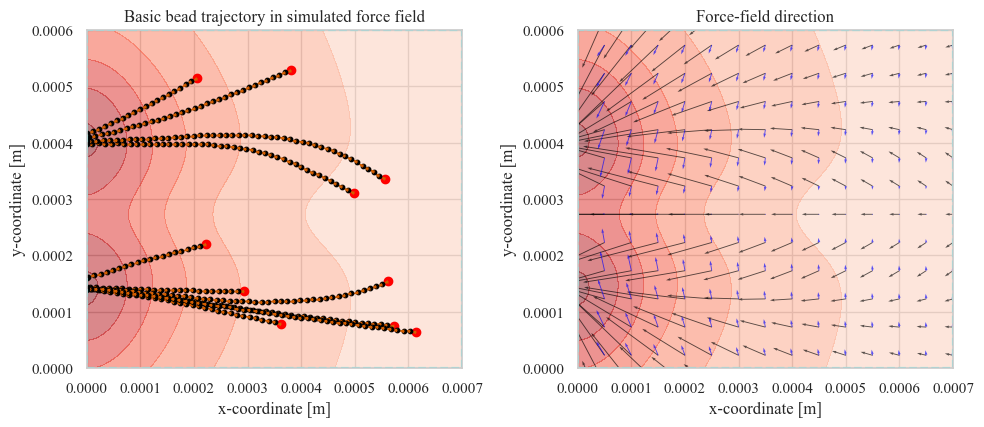

In [291]:
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (10,8))

ax1 = fig.add_subplot(2,2,1)

# ax1.contourf(xx__, yy__, test_frame, alpha = 1, cmap="binary")
CS = ax1.contourf(X1, Y1, field_dict["B"]["B_{}".format(level)], alpha = 0.5, cmap = "Reds")

x_coords = np.unique(X1)
y_coords = np.unique(Y1)

# Image-B alignment controls (all in um).
imageB_x_shift_um = 0.0
imageB_y_shift_um = 300.0

# Target ROI size from your request: width 700 um, height +/-300 um.
roi_x_nominal_um = (0.0, 700.0)
roi_y_nominal_um = (-300.0, 300.0)

roi_x_target_um = (
    roi_x_nominal_um[0] + imageB_x_shift_um,
    roi_x_nominal_um[1] + imageB_x_shift_um,
 )
roi_y_target_um = (
    roi_y_nominal_um[0] + imageB_y_shift_um,
    roi_y_nominal_um[1] + imageB_y_shift_um,
 )

x_min = max(float(x_coords.min()), roi_x_target_um[0] * 1e-6)
x_max = min(float(x_coords.max()), roi_x_target_um[1] * 1e-6)
y_min = max(float(y_coords.min()), roi_y_target_um[0] * 1e-6)
y_max = min(float(y_coords.max()), roi_y_target_um[1] * 1e-6)

if (x_max <= x_min) or (y_max <= y_min):
    raise RuntimeError(
        "Shifted ROI is outside the simulated domain. Adjust imageB_x_shift_um / imageB_y_shift_um."
    )

x_margin = 0.1 * (x_max - x_min)
y_margin = 0.1 * (y_max - y_min)
max_step = 0.02 * min(x_max - x_min, y_max - y_min)

model_bead = stateSpace_bead(
    x_coords,
    y_coords,
    field_dict["B"]["B_{}".format(level)],
    field_dict["dBx"]["dBx_{}".format(level)],
    field_dict["dBy"]["dBy_{}".format(level)],
    M_mag,
    xdata,
    mu_0,
 )

# Simple visual simulation: overdamped motion with a capped per-step displacement.
steps = 60
dt_sim = 2e-2
mobility_gain = 5e5

for traj_idx in range(10):
    x_start = np.random.uniform(low=x_min + x_margin, high=x_max - x_margin)
    y_start = np.random.uniform(low=y_min + y_margin, high=y_max - y_margin)

    bead = particle(x_start, y_start, dt_sim, steps, radius, rho)

    ax1.scatter(bead.s_x, bead.s_y, color="red")

    force_x = 0.0
    force_y = 0.0
    disp_x = 0.0
    disp_y = 0.0
    for step_idx in range(steps):
        force, force_x, force_y = model_bead.find_force(bead.s_x, bead.s_y, bead.size)
        disp_x = mobility_gain * force_x * bead.dt
        disp_y = mobility_gain * force_y * bead.dt

        disp_norm = np.hypot(disp_x, disp_y)
        if disp_norm > max_step:
            scale = max_step / max(disp_norm, 1e-18)
            disp_x *= scale
            disp_y *= scale

        ax1.quiver(
            bead.s_x,
            bead.s_y,
            disp_x,
            disp_y,
            color='r',
            angles="xy",
            scale_units='xy',
            scale=1.0,
        )

        bead.s_x = bead.s_x + disp_x
        bead.s_y = bead.s_y + disp_y
        bead.position_history[0, bead.step] = bead.s_x
        bead.position_history[1, bead.step] = bead.s_y
        bead.step += 1

        bead.s_x = np.clip(bead.s_x, x_min, x_max)
        bead.s_y = np.clip(bead.s_y, y_min, y_max)
        bead.position_history[0, bead.step - 1] = bead.s_x
        bead.position_history[1, bead.step - 1] = bead.s_y

        ax1.scatter(bead.s_x, bead.s_y, color="black", s=10)

        hit_boundary = (bead.s_x <= x_min) or (bead.s_x >= x_max) or (bead.s_y <= y_min) or (bead.s_y >= y_max)
        if hit_boundary:
            break

roi_box = Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    fill=False,
    edgecolor='cyan',
    linewidth=1.5,
    linestyle='--',
    label='Shifted ROI',
)
ax1.add_patch(roi_box)

print(f'Target ROI (with shift): x=[{roi_x_target_um[0]:.1f}, {roi_x_target_um[1]:.1f}] um, y=[{roi_y_target_um[0]:.1f}, {roi_y_target_um[1]:.1f}] um')
print(f'Applied ROI (clipped to domain): x=[{x_min*1e6:.1f}, {x_max*1e6:.1f}] um, y=[{y_min*1e6:.1f}, {y_max*1e6:.1f}] um')
print(f'Last-step force magnitude: {force:.3e} N')
print(f'Last-step displacement magnitude: {np.hypot(disp_x, disp_y):.3e} m')
print(f'Max allowed step magnitude: {max_step:.3e} m')

ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_title("Basic bead trajectory in simulated force field")
ax1.set_xlabel("x-coordinate [m]")
ax1.set_ylabel("y-coordinate [m]")

ax2 = fig.add_subplot(2,2,2)

# ax2.contourf(xx__, yy__, test_frame, alpha = 1, cmap="binary")
CS = ax2.contourf(X1, Y1, field_dict["B"]["B_{}".format(level)], alpha = 0.5, cmap = "Reds")

dBx_map = field_dict["dBx"]["dBx_{}".format(level)]
dBy_map = field_dict["dBy"]["dBy_{}".format(level)]

# Plot only one vector field here (force-direction proxy) to avoid mixed-direction clutter.
ax2.quiver(
    X1[::phase, ::phase],
    Y1[::phase, ::phase],
    dBx_map[::phase,::phase],
    dBy_map[::phase,::phase],
    angles="xy",
    color='black',
    alpha=0.65,
 )

Bx_map = field_dict["Bx"]["Bx_{}".format(level)]
By_map = field_dict["By"]["By_{}".format(level)]

# Add streamlines from the same field used in quiver for consistency.
ax2.quiver(
    X1[::phase, ::phase],
    Y1[::phase, ::phase],
    Bx_map[::phase,::phase],
    By_map[::phase,::phase],
    angles="xy",
    color='blue',
    alpha=0.65,
 )

roi_box2 = Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    fill=False,
    edgecolor='cyan',
    linewidth=1.5,
    linestyle='--',
    label='Shifted ROI',
)
ax2.add_patch(roi_box2)

ax2.set_xlim([x_min, x_max])
ax2.set_ylim([y_min, y_max])
ax2.set_title("Force-field direction")
ax2.set_xlabel("x-coordinate [m]")
ax2.set_ylabel("y-coordinate [m]")

plt.tight_layout()
plt.show()